# Entrenamiento de modelo de predicción de puntuación


## Importación de librerias necesarias


In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-11-17 02:41:40.027230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-17 02:41:40.039536: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-17 02:41:40.042970: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-17 02:41:40.051950: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 02:41:42.301843: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: []
❌ No GPU detected


I0000 00:00:1763365307.743109  390235 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-17 02:41:47.783678: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ee7d952f-7455-4b22-9b88-294aef8014a8;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 118ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = True


In [8]:
src_dir_boolean = spark_utils.path(
    'final_training_data_rating_array_boolean', catalog = GOLD_PREMODELING
)


In [9]:
from src.utils.models import BinaryModel
binary_model = BinaryModel(
    'binary_model', 
    METASTORE_PATH, 
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_boolean,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
binary_model.prepare_data(
    target_columns=[b"rating_boolean"], 
    shuffle_buffer_size=-1,
    batch_size=1024,
)

2025-11-16 07:52:07.998406: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


## Crear modelo de predicción


In [16]:
binary_model.create_model()


<Sequential name=sequential_1, built=True>

In [17]:
binary_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/binary_model.png"
)

model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model.png'

In [18]:
binary_model.input_shape

400

In [19]:
binary_model.model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_0 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,921 (570.00 KB)

 Trainable params: 145,921 (570.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
if True:
    history_model_binary = binary_model.train(epochs=10)


Epoch 1/10
   4170/Unknown 932s 222ms/step - accuracy: 0.8612 - loss: 0.3150

2025-11-16 08:17:25.126919: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.25131, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model/model_checkpoints/rating_model_epoch_01.h5


2025-11-16 08:20:08.679164: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1096s 261ms/step - accuracy: 0.8828 - loss: 0.2781 - val_accuracy: 0.8917 - val_loss: 0.2513 - learning_rate: 0.0010
Epoch 2/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.8963 - loss: 0.2496
Epoch 2: val_loss improved from 0.25131 to 0.22431, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model/model_checkpoints/rating_model_epoch_02.h5


...

4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1108s 264ms/step - accuracy: 0.9254 - loss: 0.1841 - val_accuracy: 0.9326 - val_loss: 0.1666 - learning_rate: 0.0010
Epoch 7/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9277 - loss: 0.1786
Epoch 7: val_loss improved from 0.16664 to 0.15893, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model/model_checkpoints/rating_model_epoch_07.h5


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1179s 281ms/step - accuracy: 0.9290 - loss: 0.1757 - val_accuracy: 0.9369 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 8/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9303 - loss: 0.1728
Epoch 8: val_loss improved from 0.15893 to 0.15347, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model/model_checkpoints/rating_model_epoch_08.h5


2025-11-16 10:30:32.129725: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1113s 266ms/step - accuracy: 0.9317 - loss: 0.1697 - val_accuracy: 0.9392 - val_loss: 0.1535 - learning_rate: 0.0010
Epoch 9/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9331 - loss: 0.1663
Epoch 9: val_loss improved from 0.15347 to 0.14672, saving model to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model/model_checkpoints/rating_model_epoch_09.h5


4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1103s 263ms/step - accuracy: 0.9342 - loss: 0.1636 - val_accuracy: 0.9421 - val_loss: 0.1467 - learning_rate: 0.0010
Epoch 10/10
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9352 - loss: 0.1613
Epoch 10: val_loss did not improve from 0.14672
4170/4170 ━━━━━━━━━━━━━━━━━━━━ 1104s 264ms/step - accuracy: 0.9360 - loss: 0.1596 - val_accuracy: 0.9413 - val_loss: 0.1487 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.


2025/11/16 11:07:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/16 11:07:21 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/11/16 11:07:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


c819bc60d4f44f8380ad45a7a4e4cbdb
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_model.png


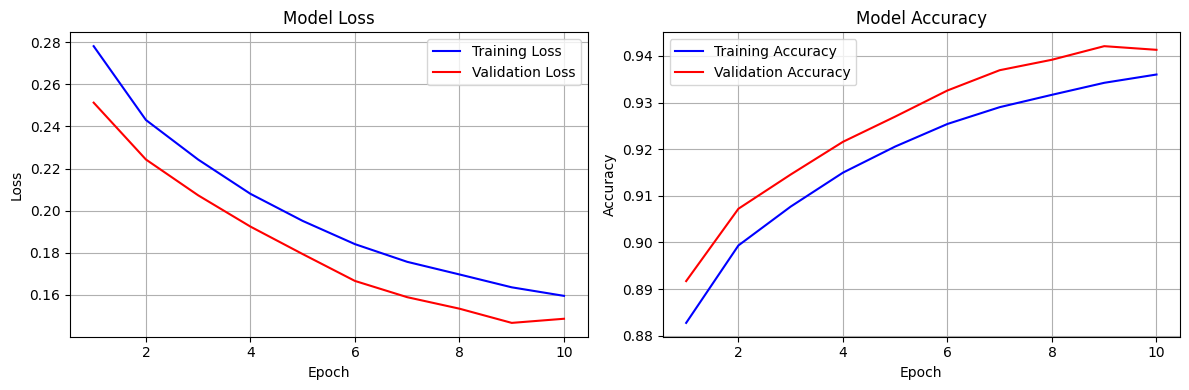

In [ ]:
if True:
    for name, model in [
        ("binary_model", binary_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        model.plot_confusion_matrix()

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


In [1]:
model.plot_confusion_matrix()

NameError: name 'model' is not defined

## Cargar modelo


In [29]:
from src.utils.models import BinaryModel
binary_model = BinaryModel(
    'binary_model', 
    METASTORE_PATH, 
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_boolean,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
binary_model.prepare_data(
    target_columns=[b"rating_boolean"], 
    shuffle_buffer_size=-1,
    batch_size=1024,
)

In [ ]:
binary_model.list_available_models()



Available Model Versions (filtered by: binary_model)

1. Run ID: a160b18118644060b3873c876b1cc488
   Run Name: binary_model_402features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-11-15 23:19:06.017000+00:00
   End Time: 2025-11-15 23:19:22.497000+00:00
   Metrics: Loss: 0.3076, Val Loss: 0.2752, Accuracy: 0.8640, Val Accuracy: 0.8878

2. Run ID: da62db697dc14ee896de1a84588f60ce
   Run Name: binary_model_376features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-11-04 04:47:56.442000+00:00
   End Time: 2025-11-04 04:48:10.334000+00:00
   Metrics: Loss: 0.0883, Val Loss: 0.4196, Accuracy: 0.9625, Val Accuracy: 0.8926

3. Run ID: 3d22f578699344afbf70825e7d74c9dc
   Run Name: binary_model_401features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-27 02:21:00.431000+00:00
   End Time: 2025-10-27 02:21:14.596000+00:00
   Metrics: Loss: 0.0650, Val Loss: 0.0420, Accuracy: 0.9717, Val Accuracy: 0.9831

4. Run ID: 195df4651b0e4630bb7a59963e15babe
   Run Name: 

In [30]:
binary_model.load_latest_model()

/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Using cached evaluation results
Confusion matrix saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model/confusion_matrix.png
Error logging confusion matrix to MLflow: Could not find experiment with ID 0


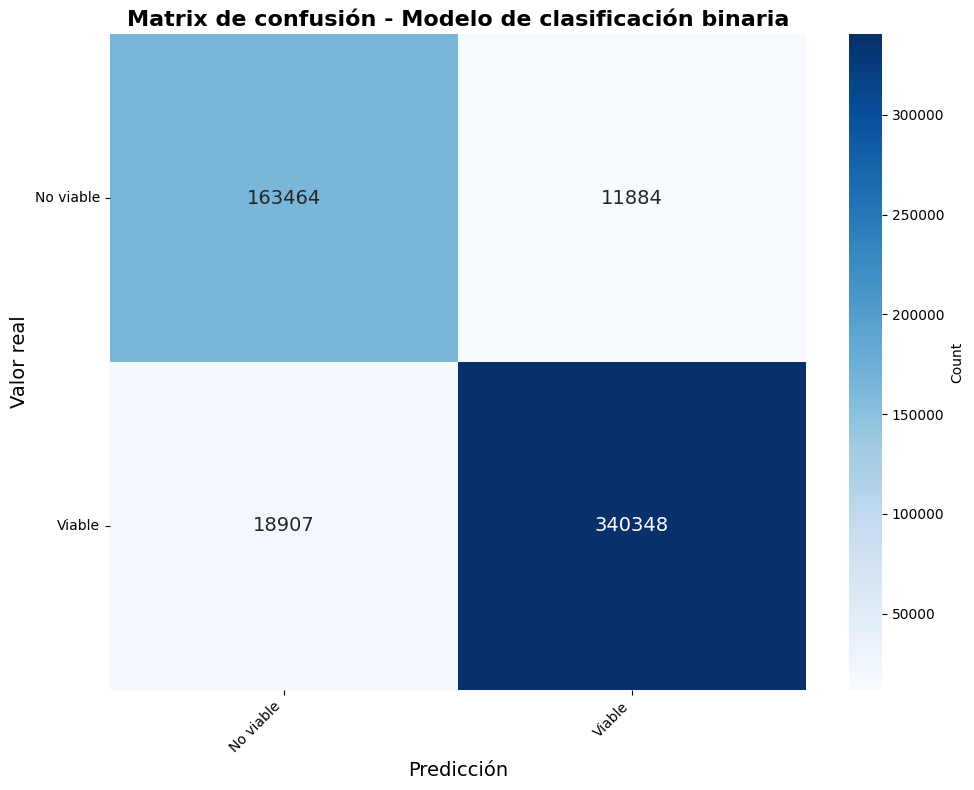

array([[163464,  11884],
       [ 18907, 340348]])

In [37]:
binary_model.plot_confusion_matrix(
    title = 'Matrix de confusión - Modelo de clasificación binaria',
    class_names = ['No viable', 'Viable'],
    xlabel = 'Predicción',
    ylabel = 'Valor real',
    annot_fontsize = 14,
    label_fontsize = 14,
)

Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_binary_model.png


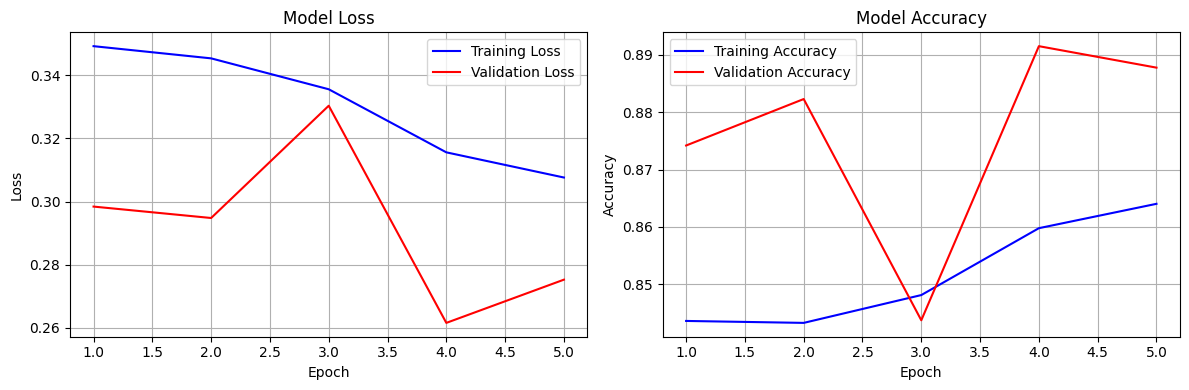

In [ ]:
binary_model.plot_latest_model_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_binary_{'binary_model'}.png"
        )

/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/old_training_history_binary_binary_model.png


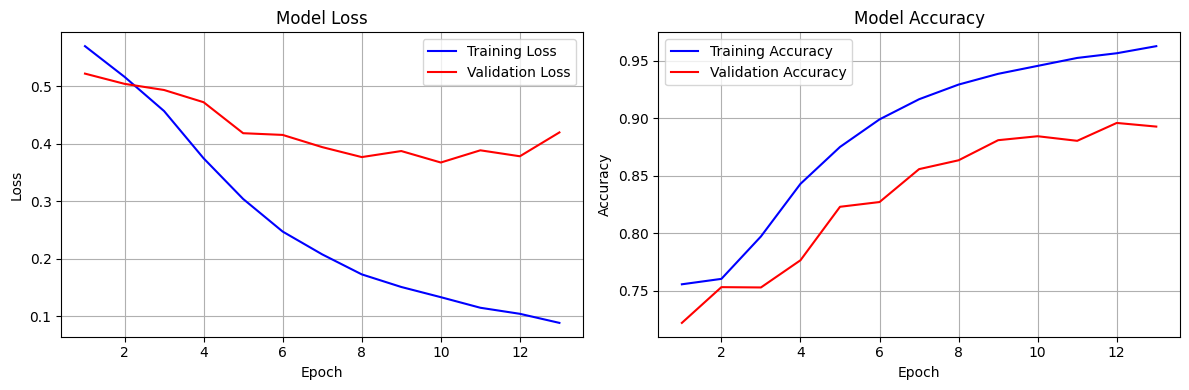

In [ ]:
binary_model.load_model(run_id='da62db697dc14ee896de1a84588f60ce')
binary_model.plot_training_history(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/old_training_history_binary_{'binary_model'}.png"
)

In [14]:
from src.utils.models import BinaryModel
binary_model = BinaryModel(
    'binary_model', 
    METASTORE_PATH, 
    tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow",
    spark_utils=spark_utils,
    target_path=src_dir_boolean,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)
binary_model.input_shape = 400
binary_model.create_model()
binary_model.model.summary()
binary_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/binary_model.png"
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_0 (Dense)                 │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,921 (570.00 KB)

 Trainable params: 145,921 (570.00 KB)

 Non-trainable params: 0 (0.00 B)

model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model.png'